# Tutorial: KeplerMapper on the Digits Dataset

The dataset is the `sklearn.datasets.load_digits()` dataset: 1,797 handwritten digit images, each represented as an 8×8 grayscale image.

## 1. Install dependencies

Run this cell if the packages are not already installed.

In [1]:
# Uncomment and run if needed:
%pip install kmapper scikit-learn numpy matplotlib pillow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## 2. Import libraries

In [8]:
import io
import sys
import base64
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import sklearn
from sklearn import datasets
from sklearn.preprocessing import MinMaxScaler
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN

import kmapper as km

try:
    from PIL import Image
except ImportError:
    raise ImportError("This notebook requires Pillow. Run `%pip install pillow` and restart the kernel.")

## 3. Load the digits dataset

The original digit images are 8×8 arrays with pixel values from 0 to 16.

The official KeplerMapper example rescales the data to the range 0 to 255 before creating image tooltips, because Pillow works naturally with 8-bit grayscale PNG images.

In [9]:
digits = datasets.load_digits()

raw_data = digits.data
labels = digits.target
images = digits.images

print("Raw data shape:", raw_data.shape)
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Unique labels:", np.unique(labels))
print("Raw pixel range:", raw_data.min(), "to", raw_data.max())

Raw data shape: (1797, 64)
Images shape: (1797, 8, 8)
Labels shape: (1797,)
Unique labels: [0 1 2 3 4 5 6 7 8 9]
Raw pixel range: 0.0 to 16.0


## 4. Preview the digit images

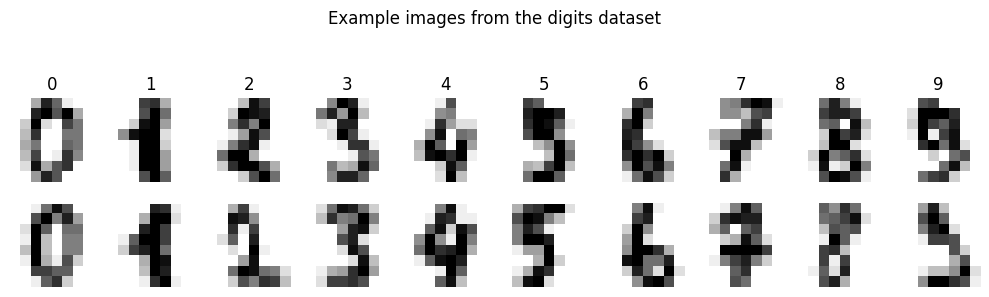

In [10]:
fig, axes = plt.subplots(2, 10, figsize=(10, 3))

for digit in range(10):
    digit_indices = np.where(labels == digit)[0]
    for row in range(2):
        idx = digit_indices[row]
        ax = axes[row, digit]
        ax.imshow(images[idx], cmap="gray_r")
        ax.set_title(str(digit) if row == 0 else "")
        ax.axis("off")

plt.suptitle("Example images from the digits dataset", y=1.05)
plt.tight_layout()
plt.show()

## 5. Rescale images for HTML tooltips

We rescale the 64 pixel features to 8-bit grayscale values from 0 to 255.

The resulting `data` array is what we will pass into KeplerMapper.

In [11]:
scaler = MinMaxScaler(feature_range=(0, 255))
data = scaler.fit_transform(raw_data).astype(np.uint8)

print("Scaled data shape:", data.shape)
print("Scaled pixel range:", data.min(), "to", data.max())

Scaled data shape: (1797, 64)
Scaled pixel range: 0 to 255


## 6. Create custom image tooltips

For each digit image:

1. Reshape the 64-pixel vector into an 8×8 image.
2. Convert it to a grayscale PNG using Pillow.
3. Encode the PNG as base64.
4. Store it as an HTML `<img>` tag.

KeplerMapper can use this array as `custom_tooltips`, so hovering over a Mapper node shows actual digit images.

In [12]:
tooltip_s = []

for image_data in data:
    with io.BytesIO() as output:
        img = Image.fromarray(image_data.reshape((8, 8)), "L")
        img = img.resize((64, 64), resample=Image.Resampling.NEAREST)
        img.save(output, "PNG")

        contents = output.getvalue()
        img_encoded = base64.b64encode(contents)

        img_tag = '<img src="data:image/png;base64,{}">'.format(
            img_encoded.decode("utf-8")
        )

        tooltip_s.append(img_tag)

# KeplerMapper expects a NumPy array here, not just a Python list.
tooltip_s = np.array(tooltip_s)

print("Number of custom image tooltips:", len(tooltip_s))
print("Example tooltip HTML prefix:")
print(tooltip_s[0][:80] + "...")

Number of custom image tooltips: 1797
Example tooltip HTML prefix:
<img src="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAAAAACPAi4CAAAA...


/tmp/ipykernel_1995693/3816998614.py:5: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(image_data.reshape((8, 8)), "L")


## 7. Initialize KeplerMapper

We use `verbose=2` to show detailed output while the projection and Mapper graph are being constructed.

In [13]:
mapper = km.KeplerMapper(verbose=2)
mapper

KeplerMapper(verbose=2)


KeplerMapper(verbose=2)

## 8. Fit and transform with t-SNE

We will use t-SNE to reduce the 64-dimensional digit vectors to a 2D lens. This lens is then used by Mapper to cover the data with overlapping regions. To make notebook runs more reproducible, this version sets `random_state=42`.

In [19]:
tsne = TSNE(
    n_components=2,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

projected_data = mapper.fit_transform(
    data,
    projection=tsne
)

print("Projected data shape:", projected_data.shape)

..Composing projection pipeline of length 1:
	Projections: TSNE(random_state=42)
	Distance matrices: False
	Scalers: MinMaxScaler()
..Projecting on data shaped (1797, 64)

..Projecting data using: 
	TSNE(random_state=42, verbose=2)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1797 samples in 0.000s...
[t-SNE] Computed neighbors for 1797 samples in 0.053s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1797
[t-SNE] Computed conditional probabilities for sample 1797 / 1797
[t-SNE] Mean sigma: 186.389054
[t-SNE] Computed conditional probabilities in 0.060s
[t-SNE] Iteration 50: error = 67.4703674, gradient norm = 0.0425018 (50 iterations in 0.393s)
[t-SNE] Iteration 100: error = 62.6579933, gradient norm = 0.0069542 (50 iterations in 0.332s)
[t-SNE] Iteration 150: error = 61.8398857, gradient norm = 0.0031816 (50 iterations in 0.335s)
[t-SNE] Iteration 200: error = 61.5379333, gradient norm = 0.0020012 (50 iterations in 0.334s)
[t-SNE] Iteration 250: error = 

## 9. Visualize the t-SNE lens

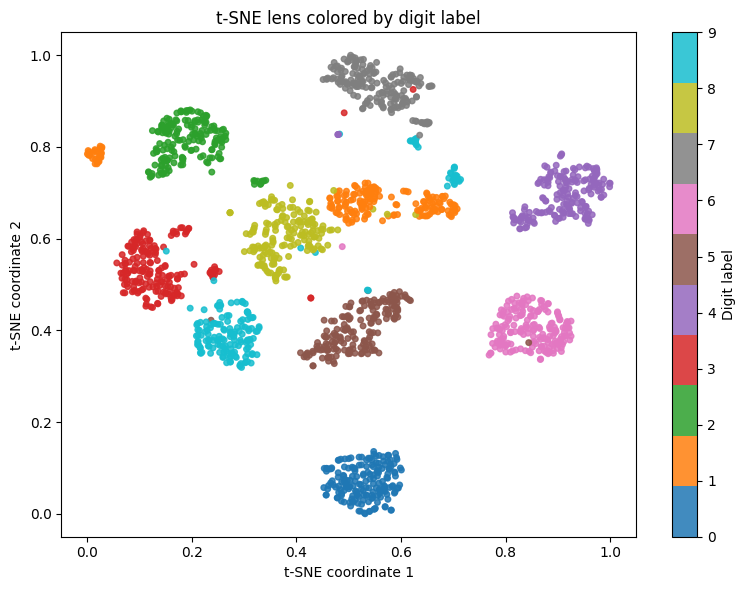

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    projected_data[:, 0],
    projected_data[:, 1],
    c=labels,
    cmap="tab10",
    s=16,
    alpha=0.85
)

ax.set_title("t-SNE lens colored by digit label")
ax.set_xlabel("t-SNE coordinate 1")
ax.set_ylabel("t-SNE coordinate 2")

cbar = plt.colorbar(scatter, ax=ax, ticks=range(10))
cbar.set_label("Digit label")

plt.tight_layout()
plt.show()

## 10. Create the Mapper graph

This follows the official gallery example:

- Clusterer: `DBSCAN(eps=0.3, min_samples=15)`
- Cover: `km.Cover(35, 0.4)`

A note on the official example: it clusters on the projected t-SNE data, which means the Mapper graph is based on the 2D projection rather than the full 64-dimensional pixel space. This can produce cleaner visual output for teaching, but it also means the graph inherits the distortions and simplifications of t-SNE.

In [21]:
graph = mapper.map(
    projected_data,
    clusterer=DBSCAN(eps=0.3, min_samples=15),
    cover=km.Cover(35, 0.4),
)

print("Graph dictionary keys:", graph.keys())
print("Number of Mapper nodes:", len(graph["nodes"]))
print("Number of Mapper links:", sum(len(v) for v in graph["links"].values()))

Mapping on data shaped (1797, 2) using lens shaped (1797, 2)

Minimal points in hypercube before clustering: 15
Creating 1225 hypercubes.
Cube_0 is empty.

   > Found 1 clusters in hypercube 1.
Cube_2 is empty.

Cube_3 is empty.

Cube_4 is empty.

Cube_5 is empty.

Cube_6 is empty.

Cube_7 is empty.

Cube_8 is empty.

Cube_9 is empty.

Cube_10 is empty.

   > Found 1 clusters in hypercube 11.
   > Found 1 clusters in hypercube 12.
Cube_13 is empty.

Cube_14 is empty.

Cube_15 is empty.

Cube_16 is empty.

Cube_17 is empty.

   > Found 1 clusters in hypercube 18.
   > Found 1 clusters in hypercube 19.
   > Found 1 clusters in hypercube 20.
   > Found 1 clusters in hypercube 21.
   > Found 1 clusters in hypercube 22.
Cube_23 is empty.

Cube_24 is empty.

Cube_25 is empty.

   > Found 1 clusters in hypercube 26.
   > Found 1 clusters in hypercube 27.
   > Found 1 clusters in hypercube 28.
   > Found 1 clusters in hypercube 29.
   > Found 1 clusters in hypercube 30.
Cube_31 is empty.

Cube

## 11. Visualization: image tooltips

Hovering over Mapper nodes displays the actual digit images assigned to those nodes.

In [22]:
image_tooltip_html = "digits_custom_tooltips.html"

mapper.visualize(
    graph,
    title="Handwritten digits Mapper: image tooltips",
    path_html=str(image_tooltip_html),
    color_values=labels,
    color_function_name="labels",
    custom_tooltips=tooltip_s,
)

print("Saved:", image_tooltip_html)

Wrote visualization to: digits_custom_tooltips.html
Saved: digits_custom_tooltips.html


## 12. Summarize Mapper nodes

Each Mapper node contains several original digit samples. We can summarize each node by:

- Node size
- Majority digit
- Purity, meaning the fraction of samples in the node belonging to the majority digit

In [24]:
def summarize_mapper_nodes(graph, labels):
    rows = []

    for node_id, members in graph["nodes"].items():
        members = np.array(members)
        node_labels = labels[members]

        values, counts = np.unique(node_labels, return_counts=True)
        majority_digit = values[np.argmax(counts)]
        purity = counts.max() / counts.sum()

        row = {
            "node": node_id,
            "size": len(members),
            "majority_digit": int(majority_digit),
            "purity": float(purity),
        }

        for digit in range(10):
            row[f"count_{digit}"] = int(np.sum(node_labels == digit))

        rows.append(row)

    return rows


node_summary = summarize_mapper_nodes(graph, labels)

# Display without pandas dependency.
node_summary_sorted = sorted(node_summary, key=lambda row: (-row["purity"], -row["size"]))

print("Top 10 purest nodes with at least 10 samples:")
shown = 0
for row in node_summary_sorted:
    if row["size"] >= 10:
        print({
            "node": row["node"],
            "size": row["size"],
            "majority_digit": row["majority_digit"],
            "purity": round(row["purity"], 3),
        })
        shown += 1
    if shown == 10:
        break

Top 10 purest nodes with at least 10 samples:
{'node': 'cube254_cluster0', 'size': 36, 'majority_digit': 1, 'purity': 1.0}
{'node': 'cube296_cluster0', 'size': 32, 'majority_digit': 7, 'purity': 1.0}
{'node': 'cube389_cluster0', 'size': 32, 'majority_digit': 6, 'purity': 1.0}
{'node': 'cube215_cluster0', 'size': 31, 'majority_digit': 0, 'purity': 1.0}
{'node': 'cube259_cluster0', 'size': 31, 'majority_digit': 7, 'purity': 1.0}
{'node': 'cube40_cluster0', 'size': 30, 'majority_digit': 3, 'purity': 1.0}
{'node': 'cube236_cluster0', 'size': 30, 'majority_digit': 7, 'purity': 1.0}
{'node': 'cube264_cluster0', 'size': 30, 'majority_digit': 0, 'purity': 1.0}
{'node': 'cube330_cluster0', 'size': 30, 'majority_digit': 1, 'purity': 1.0}
{'node': 'cube21_cluster0', 'size': 29, 'majority_digit': 3, 'purity': 1.0}


## 13. Find mixed nodes

Mixed nodes contain multiple digit labels. These are often interesting because they may represent ambiguous handwriting styles or transitions in the t-SNE lens.

In [25]:
mixed_nodes = sorted(
    [row for row in node_summary if row["size"] >= 10],
    key=lambda row: (row["purity"], -row["size"])
)

print("Top 10 mixed nodes with at least 10 samples:")
for row in mixed_nodes[:10]:
    compact = {
        "node": row["node"],
        "size": row["size"],
        "majority_digit": row["majority_digit"],
        "purity": round(row["purity"], 3),
    }
    compact.update({f"count_{d}": row[f"count_{d}"] for d in range(10) if row[f"count_{d}"] > 0})
    print(compact)

Top 10 mixed nodes with at least 10 samples:
{'node': 'cube166_cluster0', 'size': 19, 'majority_digit': 8, 'purity': 0.895, 'count_8': 17, 'count_9': 2}
{'node': 'cube272_cluster0', 'size': 19, 'majority_digit': 5, 'purity': 0.895, 'count_5': 17, 'count_9': 2}
{'node': 'cube89_cluster0', 'size': 15, 'majority_digit': 9, 'purity': 0.933, 'count_5': 1, 'count_9': 14}
{'node': 'cube327_cluster0', 'size': 15, 'majority_digit': 7, 'purity': 0.933, 'count_3': 1, 'count_7': 14}
{'node': 'cube182_cluster0', 'size': 17, 'majority_digit': 8, 'purity': 0.941, 'count_8': 16, 'count_9': 1}
{'node': 'cube319_cluster0', 'size': 17, 'majority_digit': 1, 'purity': 0.941, 'count_1': 16, 'count_8': 1}
{'node': 'cube331_cluster0', 'size': 17, 'majority_digit': 1, 'purity': 0.941, 'count_1': 16, 'count_9': 1}
{'node': 'cube227_cluster0', 'size': 18, 'majority_digit': 1, 'purity': 0.944, 'count_1': 17, 'count_8': 1}
{'node': 'cube366_cluster0', 'size': 19, 'majority_digit': 6, 'purity': 0.947, 'count_5': 1,

## 14. Key takeaway

In this notebook, we implemented the KeplerMapper digits example as a tutorial.

The main workflow was:

1. Load handwritten digit images.
2. Rescale pixel values to 8-bit grayscale.
3. Create image-based HTML tooltips.
4. Use t-SNE as a 2D Mapper lens.
5. Build a Mapper graph with DBSCAN and a high-overlap cover.
6. Generate interactive HTML visualizations.
7. Inspect pure and mixed Mapper nodes.